# path and libraries

In [3]:
# ============================================================
# CELL 1: IMPORTS AND PATH CONFIGURATION
# ============================================================

import os
import cv2
import numpy as np
import tensorflow as tf

from pathlib import Path
from tqdm.auto import tqdm


# ============================================================
# 1. BASE DATASET PATH
# ============================================================

DATASET_PATH = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET"
)


# ============================================================
# 2. PREPROCESSED CLASSIFICATION DATASET
# ============================================================
#
# These are the classification images that will be passed
# through the trained U-Net.
#
# Change this name ONLY if your actual folder has a
# different name.
# ============================================================

CLASSIFICATION_PREPROCESSED_PATH = (
    DATASET_PATH / "Classification_Preprocessed"
)


# ============================================================
# 3. SAVED U-NET MODEL
# ============================================================

MODEL_PATH = Path(
    r"C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras"
)


# ============================================================
# 4. OUTPUT ROI DATASET
# ============================================================

ROI_DATASET_PATH = (
    DATASET_PATH / "Tumor_ROI"
)


# ============================================================
# 5. IMAGE SIZE
# ============================================================
#
# Same size used during U-Net training.
# ============================================================

IMG_SIZE = 256


# ============================================================
# 6. U-NET PREDICTION THRESHOLD
# ============================================================
#
# U-Net outputs probabilities between 0 and 1.
# Pixels >= 0.5 are considered tumor.
# ============================================================

THRESHOLD = 0.5


# ============================================================
# DISPLAY CONFIGURATION
# ============================================================

print("=" * 60)
print("TUMOR ROI GENERATION")
print("=" * 60)

print("\nDataset Path:")
print(DATASET_PATH)

print("\nClassification Preprocessed Path:")
print(CLASSIFICATION_PREPROCESSED_PATH)

print("\nU-Net Model:")
print(MODEL_PATH)

print("\nROI Output Path:")
print(ROI_DATASET_PATH)

print("\nImage Size:", IMG_SIZE)
print("Threshold:", THRESHOLD)

TUMOR ROI GENERATION

Dataset Path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET

Classification Preprocessed Path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Classification_Preprocessed

U-Net Model:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\MODELS\best_unet.keras

ROI Output Path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Tumor_ROI

Image Size: 256
Threshold: 0.5


# Verification 

In [4]:
# ============================================================
# CELL 2: VERIFY CLASSIFICATION DATASET
# ============================================================

# Check whether the preprocessing folder exists
if not CLASSIFICATION_PREPROCESSED_PATH.exists():

    print("ERROR: Preprocessed classification dataset not found.")
    print("\nExpected path:")
    print(CLASSIFICATION_PREPROCESSED_PATH)

else:

    print("Preprocessed classification dataset found.")
    print("\nDataset structure:")
    print("-" * 50)

    # Get train and test folders
    train_path = CLASSIFICATION_PREPROCESSED_PATH / "train"
    test_path = CLASSIFICATION_PREPROCESSED_PATH / "test"

    # Check train folder
    if train_path.exists():

        print("\nTRAIN:")

        train_classes = sorted([
            folder.name
            for folder in train_path.iterdir()
            if folder.is_dir()
        ])

        for class_name in train_classes:

            class_path = train_path / class_name

            image_count = len([
                file
                for file in class_path.iterdir()
                if file.is_file()
                and file.suffix.lower() in [
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".tif",
                    ".tiff"
                ]
            ])

            print(
                f"  {class_name}: {image_count} images"
            )

    else:

        print("\nWARNING: Train folder not found.")

    # Check test folder
    if test_path.exists():

        print("\nTEST:")

        test_classes = sorted([
            folder.name
            for folder in test_path.iterdir()
            if folder.is_dir()
        ])

        for class_name in test_classes:

            class_path = test_path / class_name

            image_count = len([
                file
                for file in class_path.iterdir()
                if file.is_file()
                and file.suffix.lower() in [
                    ".jpg",
                    ".jpeg",
                    ".png",
                    ".bmp",
                    ".tif",
                    ".tiff"
                ]
            ])

            print(
                f"  {class_name}: {image_count} images"
            )

    else:

        print("\nWARNING: Test folder not found.")

Preprocessed classification dataset found.

Dataset structure:
--------------------------------------------------

TRAIN:
  glioma: 1147 images
  meningioma: 1329 images
  pituitary: 1457 images

TEST:
  glioma: 254 images
  meningioma: 306 images
  pituitary: 300 images


# u net verify

In [5]:
# ============================================================
# CELL 3: LOAD SAVED U-NET MODEL
# ============================================================

# ------------------------------------------------------------
# Load the already-trained U-Net model
# ------------------------------------------------------------

model = tf.keras.models.load_model(
    str(MODEL_PATH),
    compile=False
)


# ------------------------------------------------------------
# Display model information
# ------------------------------------------------------------

print("=" * 60)
print("U-NET MODEL LOADED SUCCESSFULLY")
print("=" * 60)

print("\nModel input shape:")
print(model.input_shape)

print("\nModel output shape:")
print(model.output_shape)

print("\nModel parameters:")
print(f"{model.count_params():,}")

U-NET MODEL LOADED SUCCESSFULLY

Model input shape:
(None, 256, 256, 1)

Model output shape:
(None, 256, 256, 1)

Model parameters:
31,054,145


# ROi output folders

In [6]:
# ============================================================
# CELL 4: CREATE ROI DATASET FOLDERS
# ============================================================

# ------------------------------------------------------------
# Create the main ROI dataset folder
# ------------------------------------------------------------

ROI_DATASET_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Create train and test folders
# ------------------------------------------------------------

ROI_TRAIN_PATH = ROI_DATASET_PATH / "train"
ROI_TEST_PATH = ROI_DATASET_PATH / "test"

ROI_TRAIN_PATH.mkdir(
    parents=True,
    exist_ok=True
)

ROI_TEST_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# Get class names from the preprocessed classification dataset
# ------------------------------------------------------------

class_names = sorted([
    folder.name
    for folder in train_path.iterdir()
    if folder.is_dir()
])


# ------------------------------------------------------------
# Create the same class structure for ROI dataset
# ------------------------------------------------------------

for class_name in class_names:

    # Train class folder
    (
        ROI_TRAIN_PATH / class_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    # Test class folder
    (
        ROI_TEST_PATH / class_name
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# Display the created structure
# ------------------------------------------------------------

print("=" * 60)
print("ROI DATASET FOLDERS CREATED")
print("=" * 60)

print("\nOutput path:")
print(ROI_DATASET_PATH)

print("\nClasses:")
for class_name in class_names:
    print(" -", class_name)

print("\nTrain path:")
print(ROI_TRAIN_PATH)

print("\nTest path:")
print(ROI_TEST_PATH)

ROI DATASET FOLDERS CREATED

Output path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Tumor_ROI

Classes:
 - glioma
 - meningioma
 - pituitary

Train path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Tumor_ROI\train

Test path:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Tumor_ROI\test


# Testing roi 

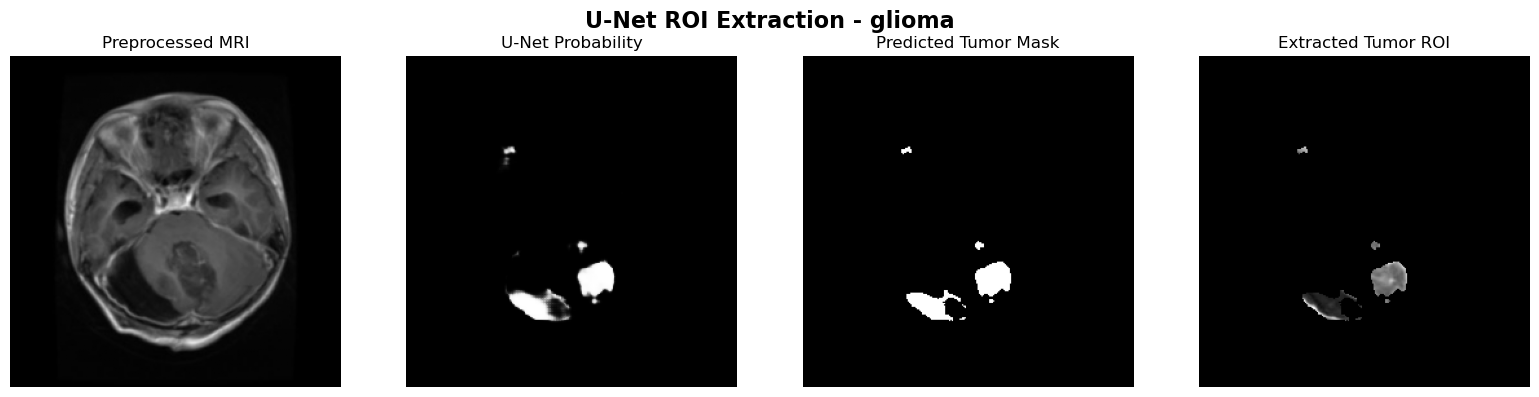

ROI EXTRACTION TEST
Class       : glioma
Image       : brisc2025_test_00001_gl_ax_t1.jpg
Image Shape : (256, 256)
Tumor Pixels: 1146
Tumor Area %: 1.75


In [7]:
# ============================================================
# CELL 5: TEST U-NET ROI EXTRACTION ON ONE IMAGE
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Select the first test image from the first class
# ------------------------------------------------------------

test_class = class_names[0]

test_class_path = test_path / test_class

test_files = [
    file
    for file in test_class_path.iterdir()
    if file.is_file()
    and file.suffix.lower() in [
        ".jpg",
        ".jpeg",
        ".png",
        ".bmp",
        ".tif",
        ".tiff"
    ]
]

test_image_path = test_files[0]


# ------------------------------------------------------------
# Read the MRI image
# ------------------------------------------------------------

original_image = cv2.imread(
    str(test_image_path),
    cv2.IMREAD_GRAYSCALE
)

if original_image is None:
    raise ValueError(
        f"Could not read image: {test_image_path}"
    )


# ------------------------------------------------------------
# Resize to U-Net input size
# ------------------------------------------------------------

image = cv2.resize(
    original_image,
    (IMG_SIZE, IMG_SIZE),
    interpolation=cv2.INTER_AREA
)


# ------------------------------------------------------------
# Normalize image to 0-1
# ------------------------------------------------------------

image_normalized = (
    image.astype(np.float32) / 255.0
)


# ------------------------------------------------------------
# Add batch and channel dimensions
# Shape becomes:
# (1, 256, 256, 1)
# ------------------------------------------------------------

model_input = np.expand_dims(
    image_normalized,
    axis=(0, -1)
)


# ------------------------------------------------------------
# Generate tumor probability mask
# ------------------------------------------------------------

prediction_probability = model.predict(
    model_input,
    verbose=0
)[0, :, :, 0]


# ------------------------------------------------------------
# Convert probability mask to binary mask
# ------------------------------------------------------------

predicted_mask = (
    prediction_probability >= THRESHOLD
).astype(np.uint8)


# ------------------------------------------------------------
# Extract tumor ROI
#
# Pixels predicted as tumor retain their MRI intensity.
# Background pixels become black.
# ------------------------------------------------------------

tumor_roi = (
    image_normalized * predicted_mask
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

plt.figure(figsize=(16, 4))


# Original MRI
plt.subplot(1, 4, 1)

plt.imshow(
    image_normalized,
    cmap="gray"
)

plt.title("Preprocessed MRI")

plt.axis("off")


# Predicted probability
plt.subplot(1, 4, 2)

plt.imshow(
    prediction_probability,
    cmap="gray",
    vmin=0,
    vmax=1
)

plt.title("U-Net Probability")

plt.axis("off")


# Binary tumor mask
plt.subplot(1, 4, 3)

plt.imshow(
    predicted_mask,
    cmap="gray"
)

plt.title("Predicted Tumor Mask")

plt.axis("off")


# Tumor ROI
plt.subplot(1, 4, 4)

plt.imshow(
    tumor_roi,
    cmap="gray"
)

plt.title("Extracted Tumor ROI")

plt.axis("off")


plt.suptitle(
    f"U-Net ROI Extraction - {test_class}",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("=" * 60)
print("ROI EXTRACTION TEST")
print("=" * 60)

print("Class       :", test_class)
print("Image       :", test_image_path.name)
print("Image Shape :", image_normalized.shape)

print(
    "Tumor Pixels:",
    np.sum(predicted_mask)
)

print(
    "Tumor Area %:",
    round(
        np.mean(predicted_mask) * 100,
        2
    )
)

# TEST U-NET MASK POST-PROCESSING

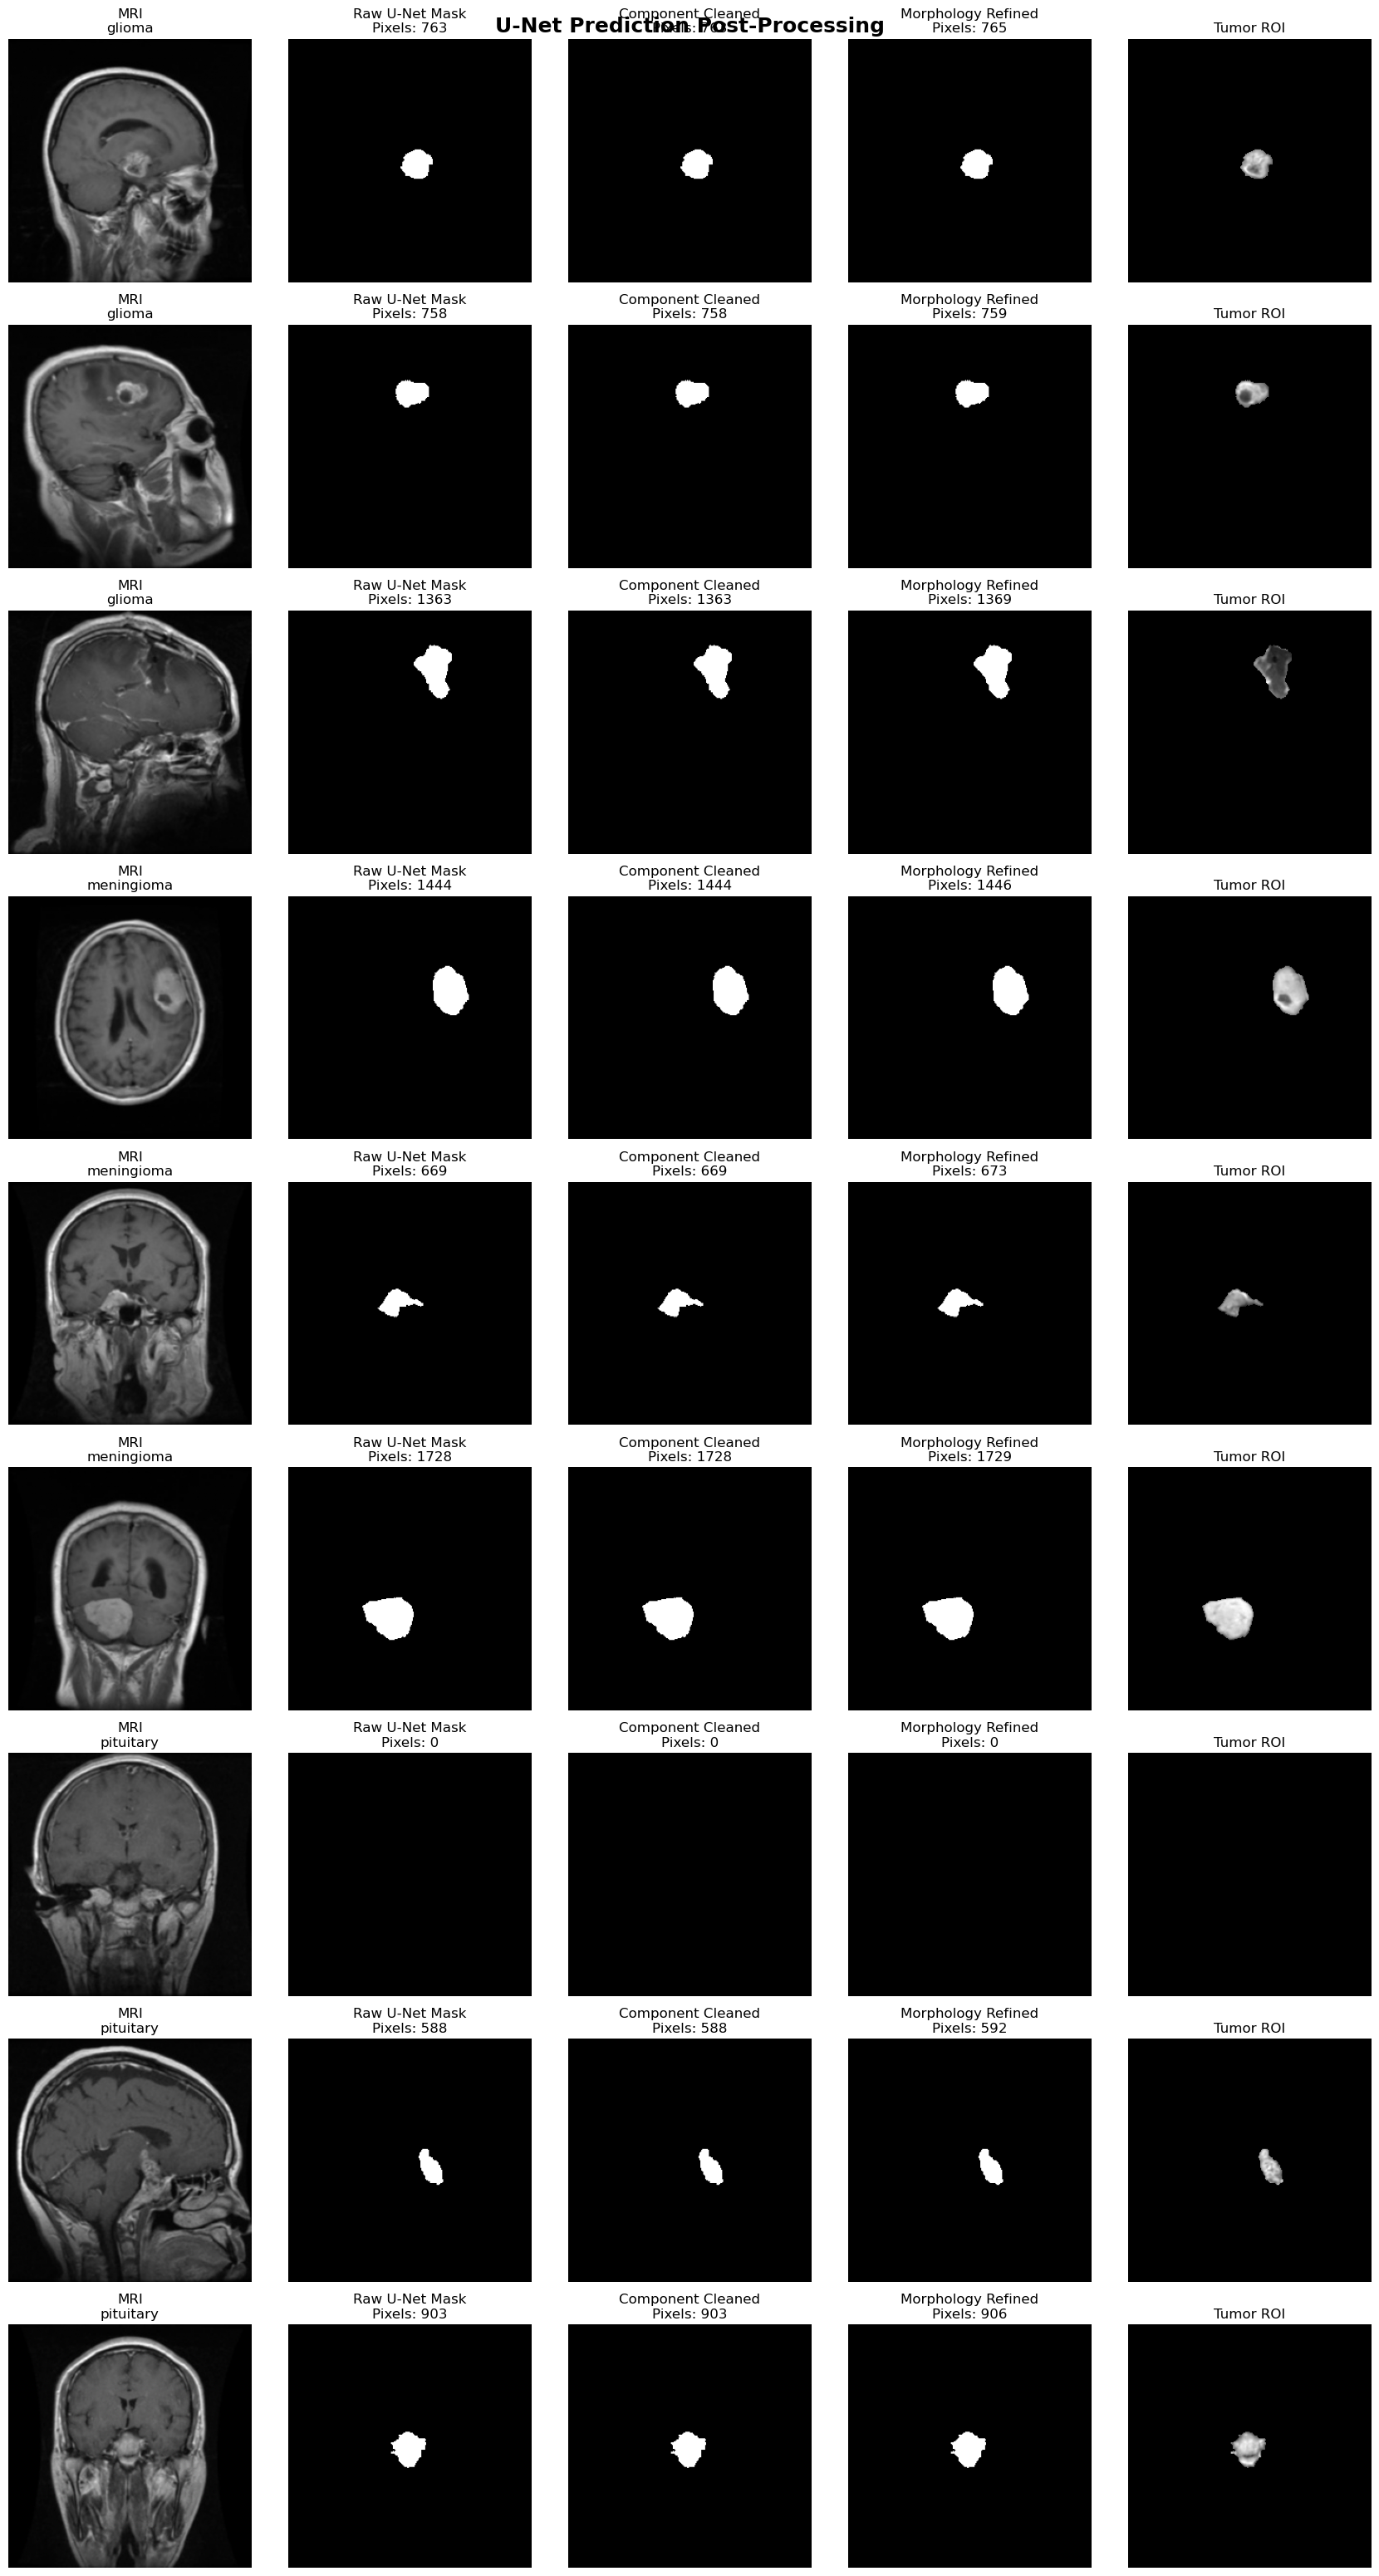

POST-PROCESSING TEST
Threshold: 0.5
Minimum component area: 50
Morphology: Closing
Morphology kernel: (3, 3)
Morphology iterations: 1
Images displayed: 9

No images were saved or modified.


In [8]:
# ============================================================
# CELL 6: TEST U-NET MASK POST-PROCESSING
# ============================================================
#
# Purpose:
#   1. Remove very small disconnected regions from the
#      U-Net predicted tumor mask.
#
#   2. Apply morphological closing to fill small holes
#      and gaps inside the predicted tumor region.
#
# IMPORTANT:
#   - This does NOT perform skull stripping.
#   - This only post-processes the U-Net tumor mask.
#   - We do NOT force the mask to keep only the largest
#     component because multiple tumor regions may be valid.
#
# Nothing is saved in this cell.
# ============================================================

import random
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Minimum connected-component area
# ------------------------------------------------------------

MIN_COMPONENT_AREA = 50


# ------------------------------------------------------------
# Morphological closing configuration
# ------------------------------------------------------------
#
# A small 3x3 elliptical kernel is used to:
#   - fill tiny holes
#   - close small gaps
#   - smooth minor discontinuities
#
# We start conservatively with one iteration.
# ------------------------------------------------------------

MORPH_KERNEL_SIZE = (3, 3)
MORPH_ITERATIONS = 1


# ------------------------------------------------------------
# Function to remove very small components
# ------------------------------------------------------------

def clean_prediction_mask(binary_mask, min_area=50):
    """
    Remove small disconnected regions from a binary
    U-Net prediction mask.

    Components smaller than min_area are removed.
    """

    # Convert mask to uint8
    mask_uint8 = (
        binary_mask.astype(np.uint8)
    )

    # Find connected components
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mask_uint8,
            connectivity=8
        )
    )

    # Create empty cleaned mask
    cleaned_mask = np.zeros_like(
        mask_uint8
    )

    # Check every connected component
    for label in range(1, num_labels):

        # Get component area
        area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        # Keep sufficiently large components
        if area >= min_area:

            cleaned_mask[
                labels == label
            ] = 1

    return cleaned_mask


# ------------------------------------------------------------
# Function for morphological closing
# ------------------------------------------------------------

def apply_morphological_closing(
    binary_mask,
    kernel_size=(3, 3),
    iterations=1
):
    """
    Apply morphological closing to a binary mask.

    Closing helps fill small holes and close small
    gaps in the predicted tumor region.
    """

    # Create elliptical structuring element
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        kernel_size
    )

    # Apply morphological closing
    refined_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=iterations
    )

    return refined_mask


# ------------------------------------------------------------
# Select random test images
# ------------------------------------------------------------

random_samples = []

for class_name in class_names:

    class_path = test_path / class_name

    files = [
        file
        for file in class_path.iterdir()
        if file.is_file()
        and file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".tif",
            ".tiff"
        ]
    ]

    # Select up to 3 images per class
    selected = random.sample(
        files,
        min(3, len(files))
    )

    random_samples.extend(
        selected
    )


# ------------------------------------------------------------
# Create visualization
#
# Each row:
#
# MRI
# Raw Mask
# Component Cleaned Mask
# Morphology Refined Mask
# Tumor ROI
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(random_samples),
    5,
    figsize=(17, 3.5 * len(random_samples))
)


# Handle case of one row
if len(random_samples) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


# ------------------------------------------------------------
# Process each random image
# ------------------------------------------------------------

for row, image_path in enumerate(
    random_samples
):

    # --------------------------------------------------------
    # Read MRI
    # --------------------------------------------------------

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        continue

    # Resize
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_AREA
    )

    # Normalize
    image_normalized = (
        image.astype(np.float32) / 255.0
    )

    # Add batch and channel dimensions
    model_input = np.expand_dims(
        image_normalized,
        axis=(0, -1)
    )

    # --------------------------------------------------------
    # U-Net prediction
    # --------------------------------------------------------

    probability = model.predict(
        model_input,
        verbose=0
    )[0, :, :, 0]

    # --------------------------------------------------------
    # Raw binary mask
    # --------------------------------------------------------

    raw_mask = (
        probability >= THRESHOLD
    ).astype(np.uint8)

    # --------------------------------------------------------
    # Connected-component cleaning
    # --------------------------------------------------------

    cleaned_mask = clean_prediction_mask(
        raw_mask,
        MIN_COMPONENT_AREA
    )

    # --------------------------------------------------------
    # Morphological closing
    # --------------------------------------------------------

    refined_mask = apply_morphological_closing(
        cleaned_mask,
        MORPH_KERNEL_SIZE,
        MORPH_ITERATIONS
    )

    # --------------------------------------------------------
    # Extract final tumor ROI
    # --------------------------------------------------------

    final_roi = (
        image_normalized * refined_mask
    )

    # --------------------------------------------------------
    # Get class name
    # --------------------------------------------------------

    class_name = image_path.parent.name

    # --------------------------------------------------------
    # Display MRI
    # --------------------------------------------------------

    axes[row, 0].imshow(
        image_normalized,
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"MRI\n{class_name}"
    )

    axes[row, 0].axis("off")

    # --------------------------------------------------------
    # Display raw U-Net mask
    # --------------------------------------------------------

    axes[row, 1].imshow(
        raw_mask,
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"Raw U-Net Mask\n"
        f"Pixels: {np.sum(raw_mask)}"
    )

    axes[row, 1].axis("off")

    # --------------------------------------------------------
    # Display connected-component cleaned mask
    # --------------------------------------------------------

    axes[row, 2].imshow(
        cleaned_mask,
        cmap="gray"
    )

    axes[row, 2].set_title(
        f"Component Cleaned\n"
        f"Pixels: {np.sum(cleaned_mask)}"
    )

    axes[row, 2].axis("off")

    # --------------------------------------------------------
    # Display morphology refined mask
    # --------------------------------------------------------

    axes[row, 3].imshow(
        refined_mask,
        cmap="gray"
    )

    axes[row, 3].set_title(
        f"Morphology Refined\n"
        f"Pixels: {np.sum(refined_mask)}"
    )

    axes[row, 3].axis("off")

    # --------------------------------------------------------
    # Display final ROI
    # --------------------------------------------------------

    axes[row, 4].imshow(
        final_roi,
        cmap="gray"
    )

    axes[row, 4].set_title(
        "Tumor ROI"
    )

    axes[row, 4].axis("off")


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

plt.suptitle(
    "U-Net Prediction Post-Processing",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Configuration information
# ------------------------------------------------------------

print("=" * 60)
print("POST-PROCESSING TEST")
print("=" * 60)

print(
    "Threshold:",
    THRESHOLD
)

print(
    "Minimum component area:",
    MIN_COMPONENT_AREA
)

print(
    "Morphology:",
    "Closing"
)

print(
    "Morphology kernel:",
    MORPH_KERNEL_SIZE
)

print(
    "Morphology iterations:",
    MORPH_ITERATIONS
)

print(
    "Images displayed:",
    len(random_samples)
)

print("\nNo images were saved or modified.")

# Generate and save all Tumor ROIs

In [10]:
# ============================================================
# CELL 7: GENERATE AND SAVE COMPLETE TUMOR ROI DATASET
# ============================================================
#
# Input:
#   Classification_Preprocessed
#
# Pipeline:
#
# Preprocessed Classification MRI
#            ↓
#      U-Net Input Format
#            ↓
#        U-Net Prediction
#            ↓
#       Probability Map
#            ↓
#       Threshold = 0.5
#            ↓
#       Raw Binary Mask
#            ↓
#  Connected Component Filtering
#            ↓
#   Morphological Closing
#            ↓
#       Empty ROI Check
#            ↓
#       Tumor ROI Extraction
#            ↓
#       Save Valid ROI
#
# IMPORTANT:
#   - Original Classification_Preprocessed images are NOT changed.
#   - Existing Tumor_ROI dataset is NOT overwritten.
#   - New ROIs are saved in Tumor_ROI_Morphology.
#   - Images with no detected ROI are skipped.
#   - Multiple valid tumor components are preserved.
# ============================================================


from tqdm.auto import tqdm


# ============================================================
# 1. CONFIGURATION
# ============================================================

BATCH_SIZE = 16

# Remove very small disconnected components
MIN_COMPONENT_AREA = 50

# Morphological closing
MORPH_KERNEL_SIZE = (3, 3)
MORPH_ITERATIONS = 1


# ============================================================
# 2. OUTPUT DATASET
# ============================================================
#
# IMPORTANT:
# This is a NEW folder.
#
# Your existing Tumor_ROI dataset remains untouched.
# ============================================================

ROI_MORPHOLOGY_PATH = (
    DATASET_PATH / "Tumor_ROI_Morphology"
)

ROI_TRAIN_PATH = (
    ROI_MORPHOLOGY_PATH / "train"
)

ROI_TEST_PATH = (
    ROI_MORPHOLOGY_PATH / "test"
)


# ============================================================
# 3. SUPPORTED IMAGE FORMATS
# ============================================================

SUPPORTED_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff"
]


# ============================================================
# 4. CONNECTED COMPONENT CLEANING
# ============================================================

def clean_prediction_mask(
    binary_mask,
    min_area=50
):
    """
    Remove very small disconnected components
    from the U-Net predicted binary mask.

    Components smaller than min_area are removed.

    Multiple sufficiently large components are preserved.
    """

    # Convert to uint8
    mask_uint8 = (
        binary_mask.astype(np.uint8)
    )

    # Find connected components
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mask_uint8,
            connectivity=8
        )
    )

    # Create empty cleaned mask
    cleaned_mask = np.zeros_like(
        mask_uint8
    )

    # Check every component
    for label in range(
        1,
        num_labels
    ):

        # Component area
        area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        # Keep sufficiently large components
        if area >= min_area:

            cleaned_mask[
                labels == label
            ] = 1

    return cleaned_mask


# ============================================================
# 5. MORPHOLOGICAL CLOSING
# ============================================================

def apply_morphological_closing(
    binary_mask,
    kernel_size=(3, 3),
    iterations=1
):
    """
    Apply morphological closing.

    Purpose:
        - Fill tiny holes
        - Close small gaps
        - Improve small discontinuities

    A small elliptical kernel is used so that
    the tumor boundary is not significantly changed.
    """

    # Create elliptical kernel
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        kernel_size
    )

    # Apply closing
    refined_mask = cv2.morphologyEx(
        binary_mask,
        cv2.MORPH_CLOSE,
        kernel,
        iterations=iterations
    )

    return refined_mask


# ============================================================
# 6. PROCESS ONE BATCH
# ============================================================

def process_roi_batch(
    image_batch,
    image_paths_batch,
    output_class_folder,
    model
):
    """
    Process one batch of preprocessed MRI images.

    Returns:
        successful_count
        failed_count
        empty_roi_count
    """

    successful_count = 0
    failed_count = 0
    empty_roi_count = 0

    # --------------------------------------------------------
    # Convert batch to NumPy array
    # --------------------------------------------------------

    batch_array = np.array(
        image_batch,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # U-Net prediction
    # --------------------------------------------------------

    probabilities = model.predict(
        batch_array,
        verbose=0
    )

    # --------------------------------------------------------
    # Process every prediction
    # --------------------------------------------------------

    for j in range(
        len(image_batch)
    ):

        try:

            # =================================================
            # 1. GET PROBABILITY MASK
            # =================================================

            probability = probabilities[
                j,
                :,
                :,
                0
            ]

            # =================================================
            # 2. THRESHOLD
            # =================================================

            raw_mask = (
                probability >= THRESHOLD
            ).astype(np.uint8)

            # =================================================
            # 3. CONNECTED COMPONENT FILTERING
            # =================================================

            cleaned_mask = (
                clean_prediction_mask(
                    raw_mask,
                    MIN_COMPONENT_AREA
                )
            )

            # =================================================
            # 4. MORPHOLOGICAL CLOSING
            # =================================================

            refined_mask = (
                apply_morphological_closing(
                    cleaned_mask,
                    MORPH_KERNEL_SIZE,
                    MORPH_ITERATIONS
                )
            )

            # =================================================
            # 5. CHECK FOR EMPTY ROI
            # =================================================

            roi_pixels = np.sum(
                refined_mask
            )

            if roi_pixels == 0:

                empty_roi_count += 1

                continue

            # =================================================
            # 6. EXTRACT TUMOR ROI
            # =================================================

            roi = (
                image_batch[j][:, :, 0]
                * refined_mask
            )

            # =================================================
            # 7. CONVERT TO 8-BIT IMAGE
            # =================================================

            roi = (
                roi * 255
            ).astype(np.uint8)

            # =================================================
            # 8. OUTPUT FILE
            # =================================================

            output_file = (
                output_class_folder
                / image_paths_batch[j].name
            )

            # =================================================
            # 9. SAVE ROI
            # =================================================

            success = cv2.imwrite(
                str(output_file),
                roi
            )

            if success:

                successful_count += 1

            else:

                failed_count += 1

        except Exception as e:

            failed_count += 1

            print(
                f"\nError processing "
                f"{image_paths_batch[j].name}: {e}"
            )

    return (
        successful_count,
        failed_count,
        empty_roi_count
    )


# ============================================================
# 7. GENERATE ROIS FOR ONE DATASET SPLIT
# ============================================================

def generate_and_save_rois(
    input_split_path,
    output_split_path,
    model
):
    """
    Generate tumor ROIs for one dataset split.

    Example:

        Classification_Preprocessed/train
                    ↓
        Tumor_ROI_Morphology/train

    Class folders are preserved.
    """

    # --------------------------------------------------------
    # Counters
    # --------------------------------------------------------

    total_images = 0
    successful_images = 0
    failed_images = 0
    empty_roi_images = 0

    # --------------------------------------------------------
    # Get class folders
    # --------------------------------------------------------

    class_folders = sorted([
        folder
        for folder in input_split_path.iterdir()
        if folder.is_dir()
    ])

    # --------------------------------------------------------
    # Process each class
    # --------------------------------------------------------

    for class_folder in class_folders:

        class_name = class_folder.name

        print(
            f"\nProcessing class: {class_name}"
        )

        # ----------------------------------------------------
        # Create output class folder
        # ----------------------------------------------------

        output_class_folder = (
            output_split_path
            / class_name
        )

        output_class_folder.mkdir(
            parents=True,
            exist_ok=True
        )

        # ----------------------------------------------------
        # Find images
        # ----------------------------------------------------

        image_files = sorted([
            file
            for file in class_folder.iterdir()
            if file.is_file()
            and file.suffix.lower()
            in SUPPORTED_EXTENSIONS
        ])

        # ----------------------------------------------------
        # Batch containers
        # ----------------------------------------------------

        image_batch = []
        image_paths_batch = []

        # ----------------------------------------------------
        # Progress bar
        # ----------------------------------------------------

        progress_bar = tqdm(
            image_files,
            desc=f"ROI - {class_name}",
            unit="image"
        )

        # ====================================================
        # PROCESS EACH IMAGE
        # ====================================================

        for image_path in progress_bar:

            total_images += 1

            try:

                # =================================================
                # READ PREPROCESSED CLASSIFICATION IMAGE
                # =================================================

                image = cv2.imread(
                    str(image_path),
                    cv2.IMREAD_GRAYSCALE
                )

                if image is None:

                    failed_images += 1

                    continue

                # =================================================
                # CHECK IMAGE SIZE
                # =================================================
                #
                # Your U-Net expects IMG_SIZE × IMG_SIZE.
                #
                # If the Classification_Preprocessed image is
                # already 256×256, nothing is changed.
                #
                # If not, resize only to make it compatible
                # with the U-Net.
                # =================================================

                if image.shape != (
                    IMG_SIZE,
                    IMG_SIZE
                ):

                    image = cv2.resize(
                        image,
                        (IMG_SIZE, IMG_SIZE),
                        interpolation=cv2.INTER_AREA
                    )

                # =================================================
                # NORMALIZE FOR U-NET INPUT
                # =================================================
                #
                # Saved image files are normally uint8
                # with pixel values 0–255.
                #
                # U-Net was trained using values 0–1.
                # =================================================

                image = (
                    image.astype(np.float32)
                    / 255.0
                )

                # =================================================
                # ADD CHANNEL DIMENSION
                # =================================================

                image = np.expand_dims(
                    image,
                    axis=-1
                )

                # =================================================
                # ADD TO BATCH
                # =================================================

                image_batch.append(
                    image
                )

                image_paths_batch.append(
                    image_path
                )

                # =================================================
                # PROCESS FULL BATCH
                # =================================================

                if len(image_batch) == BATCH_SIZE:

                    (
                        saved_count,
                        failed_count,
                        empty_count
                    ) = process_roi_batch(
                        image_batch,
                        image_paths_batch,
                        output_class_folder,
                        model
                    )

                    # Update counters
                    successful_images += (
                        saved_count
                    )

                    failed_images += (
                        failed_count
                    )

                    empty_roi_images += (
                        empty_count
                    )

                    # Clear batch
                    image_batch = []
                    image_paths_batch = []

                    # Update progress
                    progress_bar.set_postfix(
                        saved=successful_images,
                        empty=empty_roi_images,
                        failed=failed_images
                    )

            except Exception as e:

                failed_images += 1

                print(
                    f"\nError reading "
                    f"{image_path.name}: {e}"
                )

        # ====================================================
        # PROCESS REMAINING IMAGES
        # ====================================================

        if len(image_batch) > 0:

            (
                saved_count,
                failed_count,
                empty_count
            ) = process_roi_batch(
                image_batch,
                image_paths_batch,
                output_class_folder,
                model
            )

            # Update counters
            successful_images += (
                saved_count
            )

            failed_images += (
                failed_count
            )

            empty_roi_images += (
                empty_count
            )

            # Clear batch
            image_batch = []
            image_paths_batch = []

    # ========================================================
    # SPLIT SUMMARY
    # ========================================================

    print("\n" + "=" * 60)
    print("ROI GENERATION COMPLETE")
    print("=" * 60)

    print(
        "Total images found :",
        total_images
    )

    print(
        "Successfully saved :",
        successful_images
    )

    print(
        "Empty ROI skipped  :",
        empty_roi_images
    )

    print(
        "Failed             :",
        failed_images
    )

    print(
        "Threshold          :",
        THRESHOLD
    )

    print(
        "Minimum component  :",
        MIN_COMPONENT_AREA
    )

    print(
        "Morphology         :",
        "Closing"
    )

    print(
        "Morphology kernel  :",
        MORPH_KERNEL_SIZE
    )

    print(
        "Morphology iterations:",
        MORPH_ITERATIONS
    )

    print("=" * 60)

    return {
        "total": total_images,
        "saved": successful_images,
        "empty": empty_roi_images,
        "failed": failed_images
    }


# ============================================================
# 8. GENERATE TRAIN ROIS
# ============================================================

print("\n")
print("#" * 60)
print("GENERATING TRAIN ROIs")
print("#" * 60)

train_roi_results = generate_and_save_rois(
    train_path,
    ROI_TRAIN_PATH,
    model
)


# ============================================================
# 9. GENERATE TEST ROIS
# ============================================================

print("\n")
print("#" * 60)
print("GENERATING TEST ROIs")
print("#" * 60)

test_roi_results = generate_and_save_rois(
    test_path,
    ROI_TEST_PATH,
    model
)


# ============================================================
# 10. FINAL DATASET SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("FINAL ROI DATASET SUMMARY")
print("=" * 60)

print("\nTRAIN:")
print(
    "  Total images   :",
    train_roi_results["total"]
)
print(
    "  Saved ROIs     :",
    train_roi_results["saved"]
)
print(
    "  Empty ROIs     :",
    train_roi_results["empty"]
)
print(
    "  Failed         :",
    train_roi_results["failed"]
)

print("\nTEST:")
print(
    "  Total images   :",
    test_roi_results["total"]
)
print(
    "  Saved ROIs     :",
    test_roi_results["saved"]
)
print(
    "  Empty ROIs     :",
    test_roi_results["empty"]
)
print(
    "  Failed         :",
    test_roi_results["failed"]
)

print("\n")
print("Output dataset:")
print(
    ROI_MORPHOLOGY_PATH
)

print("\n" + "=" * 60)
print("ROI DATASET GENERATION FINISHED")
print("=" * 60)



############################################################
GENERATING TRAIN ROIs
############################################################

Processing class: glioma


ROI - glioma:   0%|          | 0/1147 [00:00<?, ?image/s]


Processing class: meningioma


ROI - meningioma:   0%|          | 0/1329 [00:00<?, ?image/s]


ROI GENERATION COMPLETE
Total images found : 3933
Successfully saved : 3883
Empty ROI skipped  : 50
Failed             : 0
Threshold          : 0.5
Minimum component  : 50
Morphology         : Closing
Morphology kernel  : (3, 3)
Morphology iterations: 1


############################################################
GENERATING TEST ROIs
############################################################

Processing class: glioma


...


Processing class: meningioma


ROI - meningioma:   0%|          | 0/306 [00:00<?, ?image/s]


Processing class: pituitary


ROI - pituitary:   0%|          | 0/300 [00:00<?, ?image/s]


ROI GENERATION COMPLETE
Total images found : 860
Successfully saved : 830
Empty ROI skipped  : 30
Failed             : 0
Threshold          : 0.5
Minimum component  : 50
Morphology         : Closing
Morphology kernel  : (3, 3)
Morphology iterations: 1


FINAL ROI DATASET SUMMARY

TRAIN:
  Total images   : 3933
  Saved ROIs     : 3883
  Empty ROIs     : 50
  Failed         : 0

TEST:
  Total images   : 860
  Saved ROIs     : 830
  Empty ROIs     : 30
  Failed         : 0


Output dataset:
C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Tumor_ROI_Morphology

ROI DATASET GENERATION FINISHED


# roi saved check 

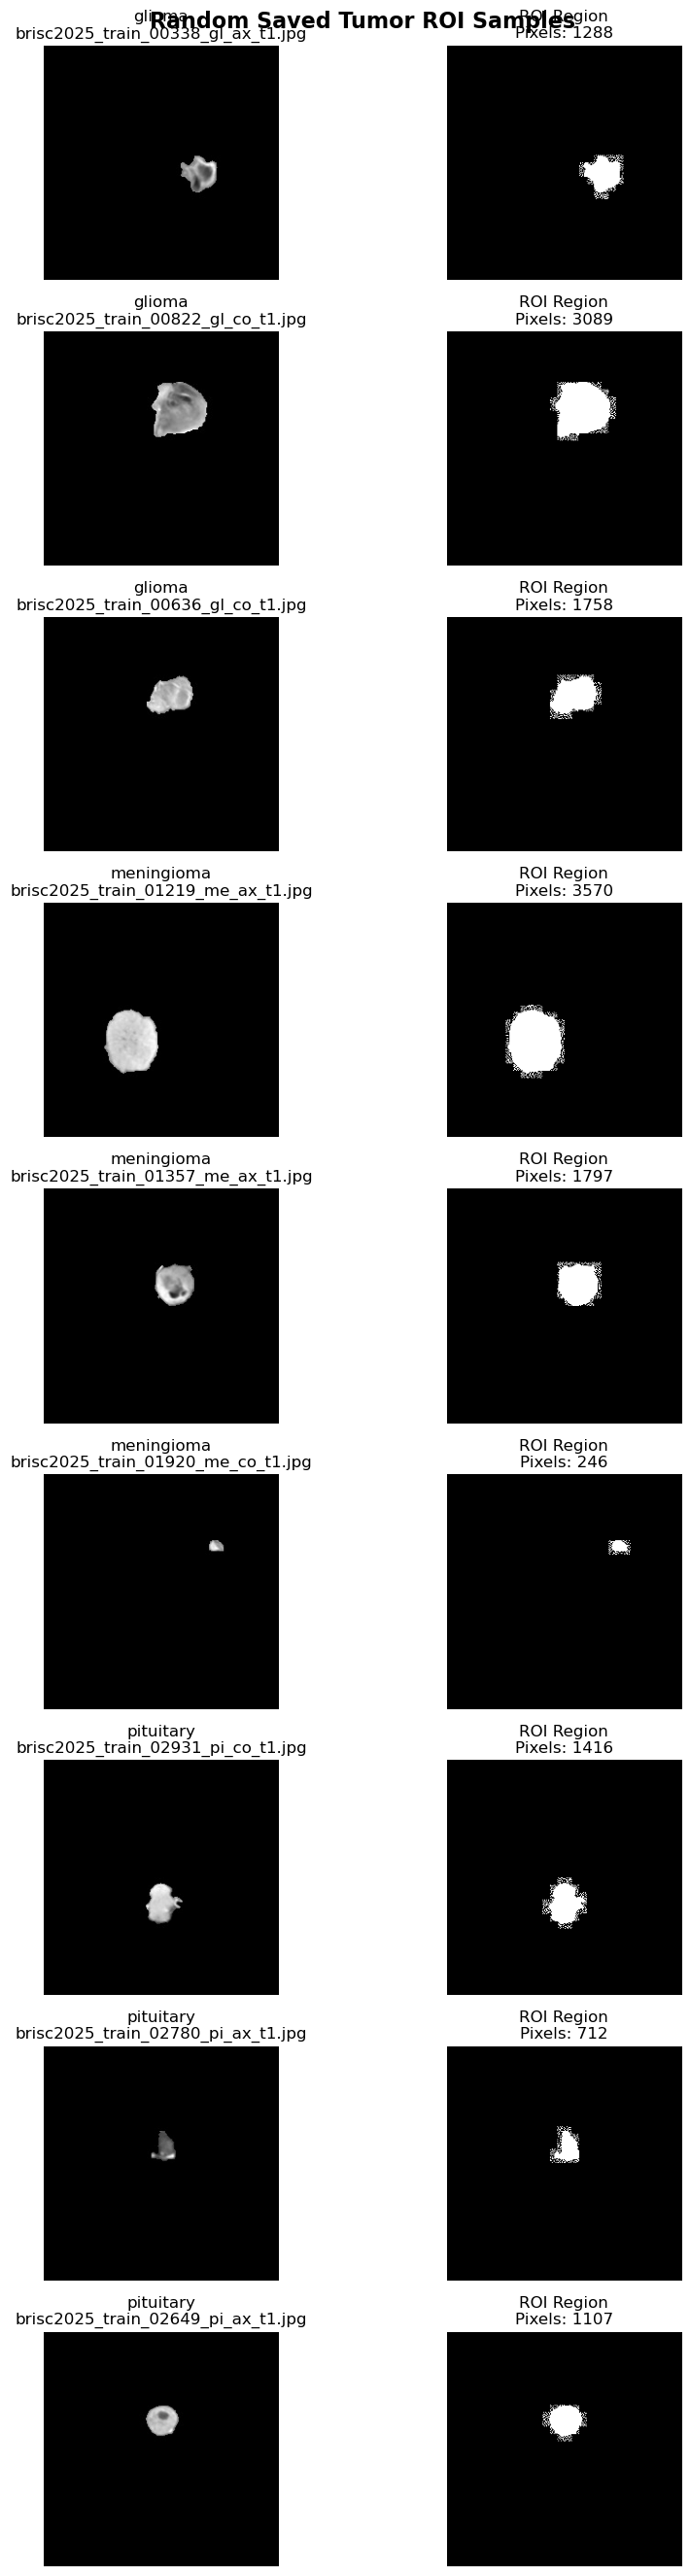

SAVED ROI DATASET VERIFICATION
Training ROI path: C:\Users\harsh\OneDrive\Documents\BE_Major_Project\DATASET\Tumor_ROI_Morphology\train
Classes: ['glioma', 'meningioma', 'pituitary']
Samples displayed: 9


In [11]:
# ============================================================
# CELL 8: VISUALIZE RANDOM SAVED ROI IMAGES
# ============================================================

import matplotlib.pyplot as plt
import random


# ------------------------------------------------------------
# Number of images to display per class
# ------------------------------------------------------------

SAMPLES_PER_CLASS = 3


# ------------------------------------------------------------
# Collect random ROI images
# ------------------------------------------------------------

roi_samples = []

for class_name in class_names:

    class_folder = ROI_TRAIN_PATH / class_name

    roi_files = [
        file
        for file in class_folder.iterdir()
        if file.is_file()
        and file.suffix.lower() in [
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
            ".tif",
            ".tiff"
        ]
    ]

    # Randomly select images
    selected_files = random.sample(
        roi_files,
        min(SAMPLES_PER_CLASS, len(roi_files))
    )

    for file in selected_files:

        roi_samples.append(
            (class_name, file)
        )


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(roi_samples),
    2,
    figsize=(10, 3 * len(roi_samples))
)


# Handle one-row case
if len(roi_samples) == 1:

    axes = np.expand_dims(
        axes,
        axis=0
    )


# ------------------------------------------------------------
# Display ROI images
# ------------------------------------------------------------

for row, (class_name, roi_path) in enumerate(
    roi_samples
):

    # Read saved ROI
    roi = cv2.imread(
        str(roi_path),
        cv2.IMREAD_GRAYSCALE
    )

    # Display ROI
    axes[row, 0].imshow(
        roi,
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"{class_name}\n{roi_path.name}"
    )

    axes[row, 0].axis("off")


    # Display binary region
    binary_roi = (
        roi > 0
    ).astype(np.uint8)

    axes[row, 1].imshow(
        binary_roi,
        cmap="gray"
    )

    axes[row, 1].set_title(
        f"ROI Region\n"
        f"Pixels: {np.sum(binary_roi)}"
    )

    axes[row, 1].axis("off")


# ------------------------------------------------------------
# Overall title
# ------------------------------------------------------------

plt.suptitle(
    "Random Saved Tumor ROI Samples",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 60)
print("SAVED ROI DATASET VERIFICATION")
print("=" * 60)

print(
    "Training ROI path:",
    ROI_TRAIN_PATH
)

print(
    "Classes:",
    class_names
)

print(
    "Samples displayed:",
    len(roi_samples)
)